In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
df=pd.read_csv('economic_index.csv')
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


# TO DROP THE NON REQUIRED COLUMNS

In [4]:
df.drop(['month'],axis=1,inplace=True)



In [5]:
df.drop(['year'],axis=1,inplace=True)
df.drop(['Unnamed: 0'],axis=1,inplace=True)

In [6]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


# TO CHECK IF THERE ARE NULL VALUES (IF ANY)

In [7]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

# visualize using seaborn

In [8]:
import seaborn as sns

In [9]:
sns.pairplot(df)



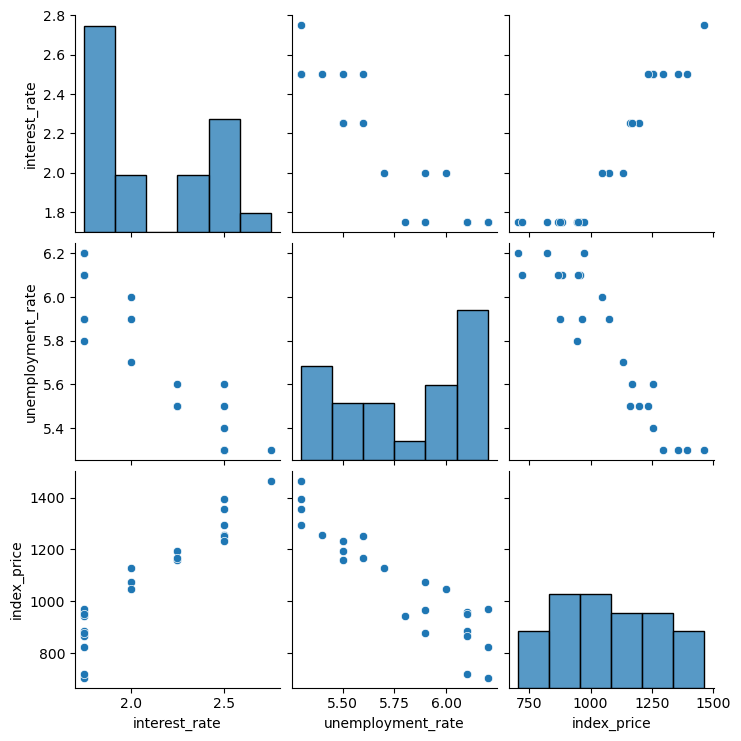

In [10]:
plt.show()


# getting the corelation

In [11]:
df.corr()


,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


# NOW GETTING THE - (X INDEPENDENT AND Y DEPENDENT)

In [12]:
x=df[['interest_rate','unemployment_rate']]
y=df['index_price']


In [13]:
x

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4
5,2.50,5.6
6,2.50,5.5
7,2.25,5.5
8,2.25,5.5
9,2.25,5.6


In [14]:
y


0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

# NOW SORTING THE TRAIN AND TEST DATA

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [16]:
x_train.shape

(18, 2)

In [17]:
x_test.shape

(6, 2)

# STANDARDIZE THE RESULTS

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


# APPLY MULTIPLE - LINEAR REGRESSION

In [19]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [20]:
regression.fit(x_train,y_train)

LinearRegression()

In [21]:
regression.coef_

array([  88.27275507, -116.25716066])

In [22]:
regression.intercept_

1053.4444444444443

# PLOT THE BEST FIT

In [23]:
x_train.shape



(18, 2)

In [24]:
y_train.shape

(18,)

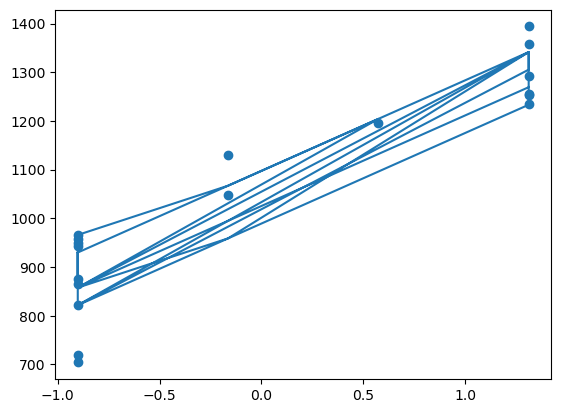

In [25]:

plt.scatter(x_train[:, 0], y_train)
plt.plot(x_train[:, 0], regression.predict(x_train))
plt.show()

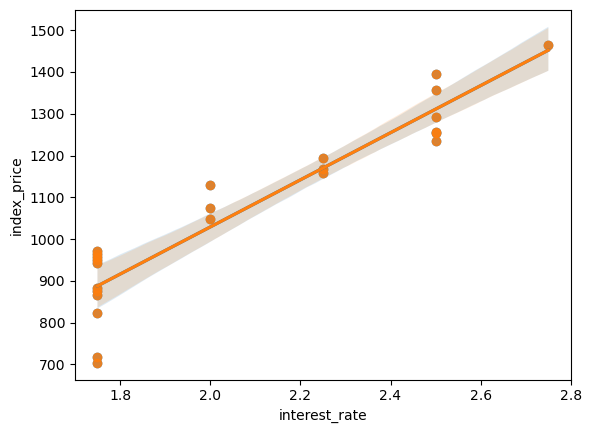

In [29]:
import seaborn as sns
sns.regplot(x=df['interest_rate'], y=df['index_price'])
plt.show()

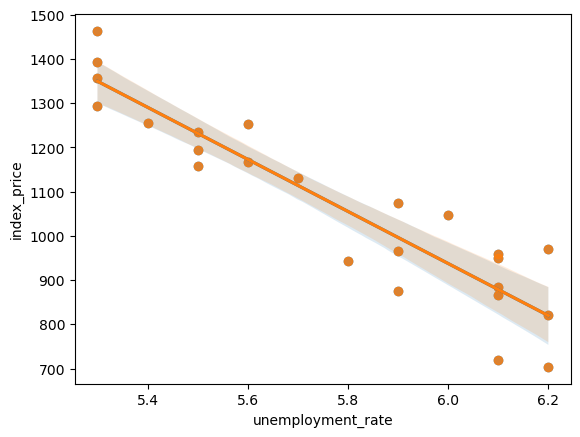

In [31]:
sns.regplot(x=df['unemployment_rate'], y=df['index_price'])
plt.show()

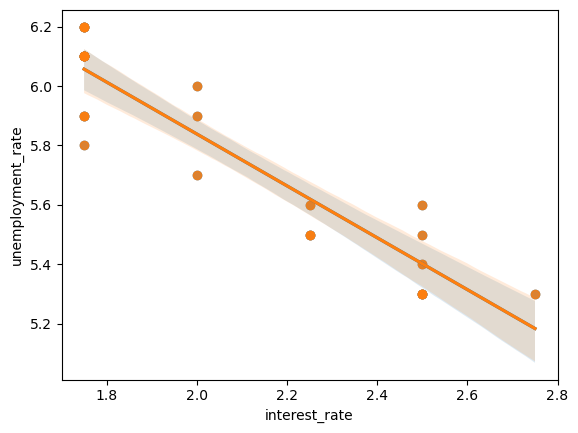

In [34]:
sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])
plt.show()

In [35]:
x_test

array([[ 0.57346234, -0.8615569 ],
       [-0.90115511,  1.30956648],
       [ 2.0480798 , -1.48187786],
       [-0.90115511,  0.999406  ],
       [-0.16384638,  0.37908503],
       [ 0.57346234, -0.55139641]])